In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import joblib

model = joblib.load(
    "../models/xgboost_energy_forecaster.pkl"
)

print(type(model))

<class 'xgboost.sklearn.XGBRegressor'>


In [8]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/energy_features.parquet"
)

TARGET = "ND"

FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30",
    "year",
    "month",
    "quarter",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "is_month_start",
    "is_month_end"
]

split_date = "2024-01-01"

test = df[df["SETTLEMENT_DATE"] >= split_date]

X_test = test[FEATURES]

In [9]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

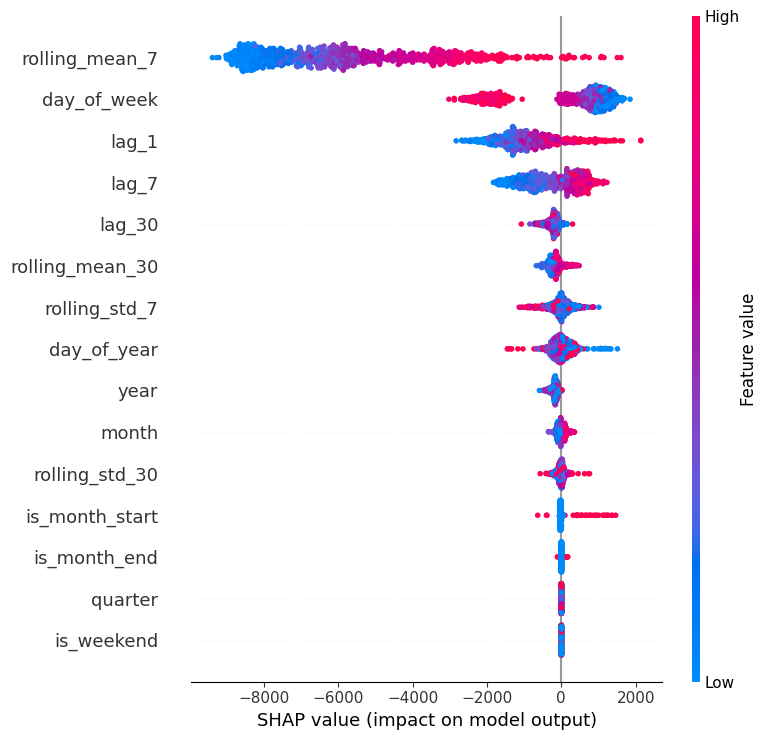

In [11]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../reports/figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

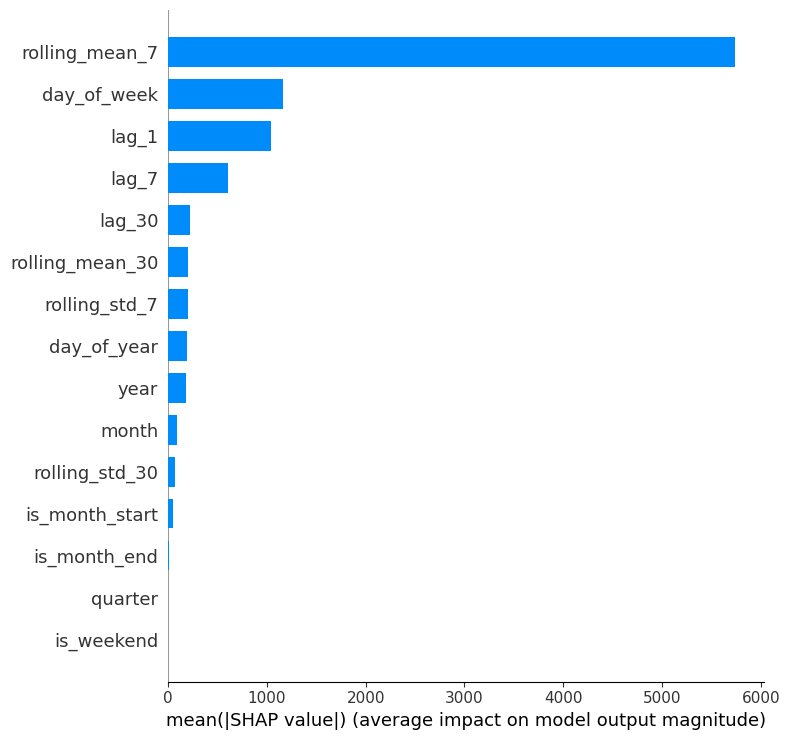

In [12]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/figures/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
import os

print(os.listdir("../models"))

['xgboost_energy_forecaster.pkl']
